## ML Evaluation Test



Import all libraries used in this homework in the cell below.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,
accuracy_score,
precision_score, recall_score,
f1_score, roc_curve,
roc_auc_score, ConfusionMatrixDisplay)


import seaborn as sns



from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score
import tensorflow as tf
from keras import layers, models
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

print(tf.config.list_physical_devices('GPU'))
# CNN model

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout



[]


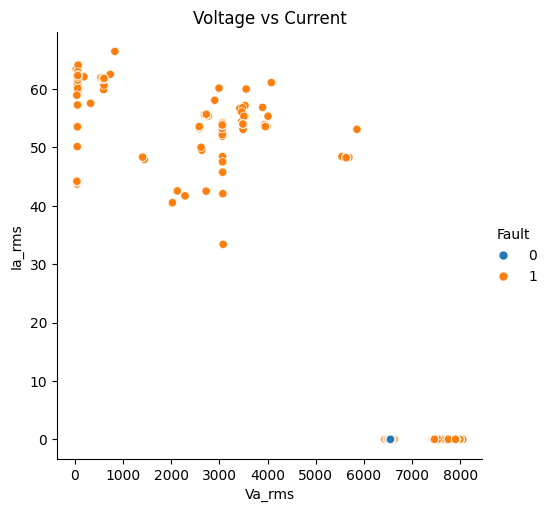

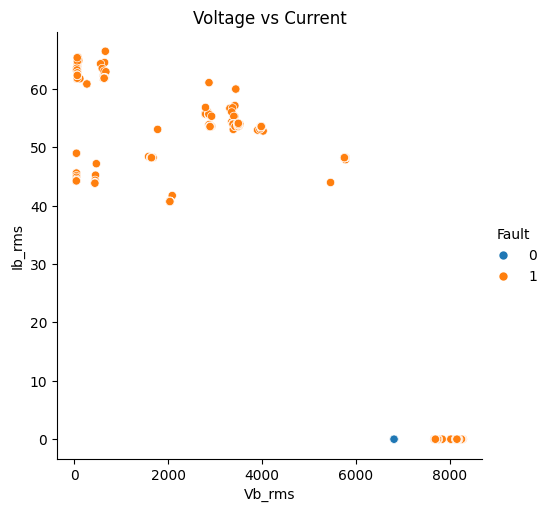

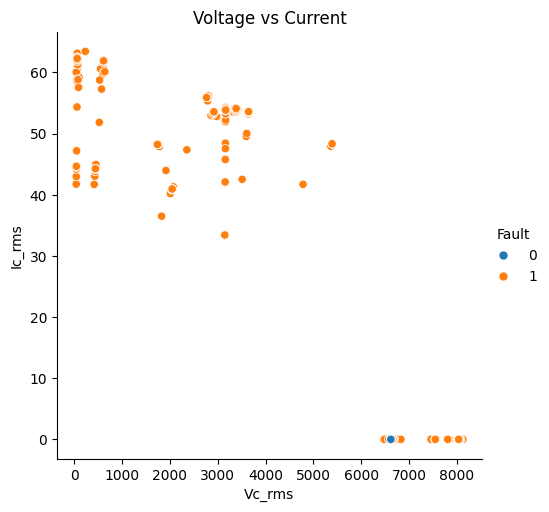

/tmp/ipykernel_195005/1869094342.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Fault', data = data_bin, palette='Set2');
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.
findfont: Font family 'Lucida Calligraphy' not found.


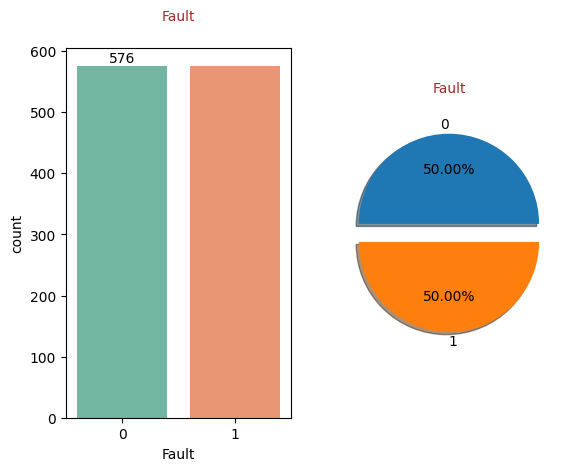

In [5]:
#Load the dataset
data_bin = pd.read_csv('Binary_fault_dataset.csv')
data_bin.head()
# Va_rms, Vb_rms, Vc_rms, Ia_rms, Ib_rms, Ic_rms, Fault (0 or 1)
# Visualize the data
# add derivative features
data_bin['dVa_rms'] = data_bin['Va_rms'].diff().fillna(0)
data_bin['dVb_rms'] = data_bin['Vb_rms'].diff().fillna(0)
data_bin['dVc_rms'] = data_bin['Vc_rms'].diff().fillna(0)
data_bin['dIa_rms'] = data_bin['Ia_rms'].diff().fillna(0)
data_bin['dIb_rms'] = data_bin['Ib_rms'].diff().fillna(0)
data_bin['dIc_rms'] = data_bin['Ic_rms'].diff().fillna(0)

sns.relplot(x='Va_rms', y='Ia_rms', hue='Fault', data=data_bin)
plt.title('Voltage vs Current')
plt.show()
sns.relplot(x='Vb_rms', y='Ib_rms', hue='Fault', data=data_bin)
plt.title('Voltage vs Current')
plt.show()
sns.relplot(x='Vc_rms', y='Ic_rms', hue='Fault', data=data_bin)
plt.title('Voltage vs Current')
plt.show()


ax = plt.subplot(1,2,1)
ax = sns.countplot(x='Fault', data = data_bin, palette='Set2');
ax.bar_label(ax.containers[0])
plt.title("Fault", fontsize=20,color = 'Brown',font='Lucida Calligraphy',pad=20)

ax =plt.subplot(1,2,2)
ax=data_bin['Fault'].value_counts().plot.pie(explode=[0.1, 0.1],autopct='%1.2f%%',shadow=True);
ax.set_title(label = "Fault", fontsize = 20,color='Brown',font='Lucida Calligraphy',pad=20);


/tmp/ipykernel_195005/1890573926.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_bin['Va_rms'], rug = True, kde = False)
/tmp/ipykernel_195005/1890573926.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_bin['Ia_rms'], color= 'green',rug = True, kde = False)
/tmp/ipykernel_19500

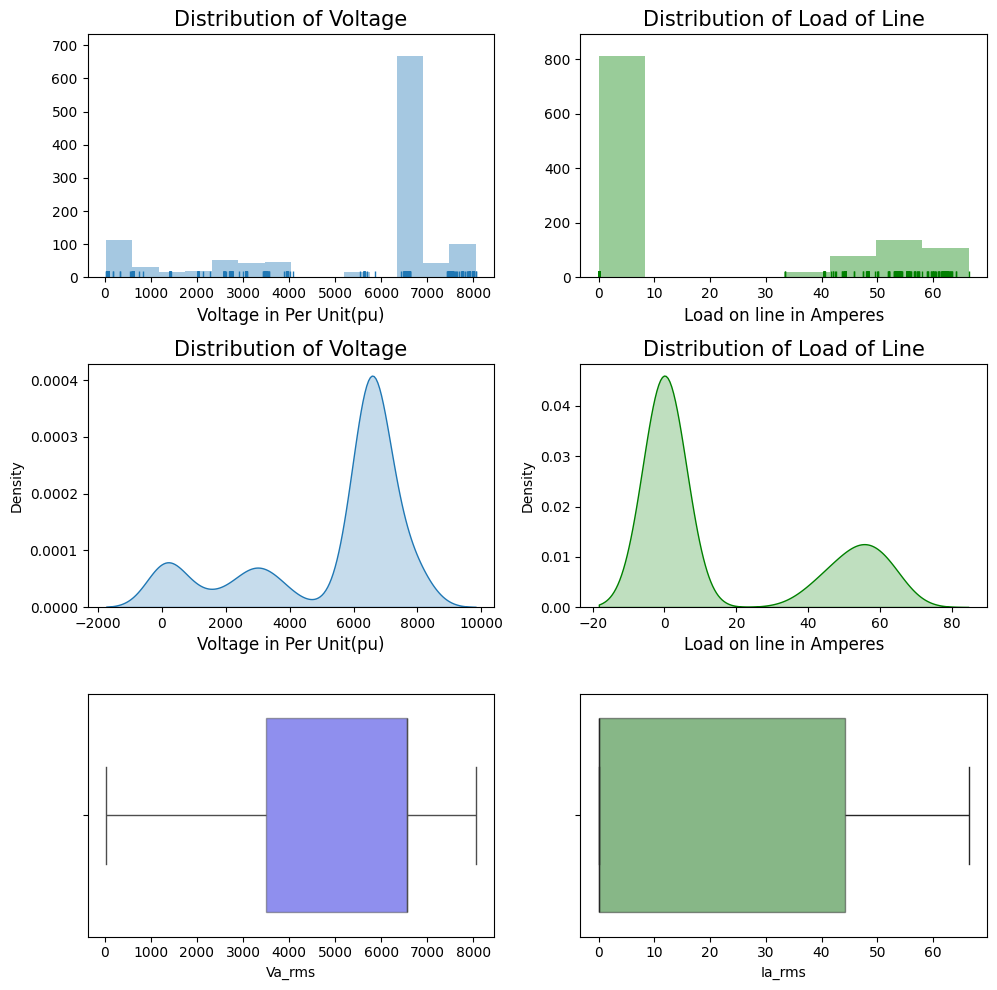

In [6]:
plt.figure(figsize= (15,10))
#plt.suptitle("Distributions of Different Features", fontsize = 20)
#Histograms
plt.subplot(3,3,1)
sns.distplot(data_bin['Va_rms'], rug = True, kde = False)
plt.xlabel('Voltage in Per Unit(pu)', fontsize = 12)
plt.title('Distribution of Voltage',fontsize = 15)

plt.subplot(3,3,2)
sns.distplot(data_bin['Ia_rms'], color= 'green',rug = True, kde = False)
plt.title('Distribution of Load of Line',fontsize = 15)
plt.xlabel('Load on line in Amperes', fontsize = 12)


#Kde Plots
plt.subplot(3,3,4)
sns.kdeplot(data_bin['Va_rms'], shade = True)
plt.xlabel('Voltage in Per Unit(pu)', fontsize = 12)
plt.title('Distribution of Voltage',fontsize = 15)

plt.subplot(3,3,5)
sns.kdeplot(data_bin['Ia_rms'], shade = True, color = 'g')
plt.title('Distribution of Load of Line',fontsize = 15)
plt.xlabel('Load on line in Amperes', fontsize = 12)


#Box Plots
plt.subplot(3,3,7)
sns.boxplot(x = data_bin['Va_rms'], orient = 'v',color= 'b', boxprops=dict(alpha=.5))
plt.subplot(3,3,8)
sns.boxplot(x = data_bin['Ia_rms'], orient = 'v', color= 'g', boxprops=dict(alpha=.5))


plt.tight_layout()
plt.show()

In [7]:
#Load the dataset
data = pd.read_csv('Line_fault_dataset.csv')
data.head()

# add derivative features added to before last 4 columns
data['dVa_rms'] = data['Va_rms'].diff().fillna(0)
data['dVb_rms'] = data['Vb_rms'].diff().fillna(0)
data['dVc_rms'] = data['Vc_rms'].diff().fillna(0)
data['dIa_rms'] = data['Ia_rms'].diff().fillna(0)
data['dIb_rms'] = data['Ib_rms'].diff().fillna(0)
data['dIc_rms'] = data['Ic_rms'].diff().fillna(0)

# add interaction features
data['Va_Ia'] = data['Va_rms'] * data['Ia_rms']
data['Vb_Ib'] = data['Vb_rms'] * data['Ib_rms']
data['Vc_Ic'] = data['Vc_rms'] * data['Ic_rms']


# remove column Fault Resistance
data = data.drop(columns=['RFault'])

# move  column 12, 13, 14, 15 to the end
cols = data.columns.tolist()
cols = cols[:18] + cols[22:] + cols[18:22]
data = data[cols]


#preprocess the data
# Create Fault_Type categorical column from A, B, C, G
def get_fault_type(row):
    faults = []
    if row['A']: faults.append('A')
    if row['B']: faults.append('B')
    if row['C']: faults.append('C')
    if row['G']: faults.append('G')
    return 'Normal' if not faults else ''.join(faults)

data['Fault_Type'] = data.apply(get_fault_type, axis=1)

# Drop A, B, C, G columns
data = data.drop(columns=['A', 'B', 'C', 'G'])

# Encode labels
le = LabelEncoder()
y = le.fit_transform(data['Fault_Type'])
X = data.drop(columns=['Fault_Type']).values

# Store classes for later use
fault_classes = le.classes_
num_classes = len(fault_classes)
print(f'Classes: {fault_classes}')
print(f'Number of classes: {num_classes}')

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)




Classes: ['AB' 'ABC' 'ABCG' 'AC' 'AG' 'BC' 'BG' 'CG' 'Normal']
Number of classes: 9


In [8]:
data.head()

,Va_rms,Vb_rms,Vc_rms,Ia_rms,Ib_rms,Ic_rms,Va_mag,Va_ang,Ra,Xa,...,dVa_rms,dVb_rms,dVc_rms,dIa_rms,dIb_rms,dIc_rms,Va_Ia,Vb_Ib,Vc_Ic,Fault_Type
0,6552.899826,6804.930627,6619.901213,0.006553,0.006805,0.006620,9267.199807,-1.601324,1000000.003,-0.108540,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,42.940497,46.307083,43.823091,Normal
1,6549.896200,6809.237388,6619.439383,0.006550,0.006809,0.006619,9262.952039,-1.601789,1000000.003,-0.108602,...,-3.003626,4.306761,-0.461830,-3.004000e-06,4.306000e-06,-4.620000e-07,42.901139,46.365711,43.816975,Normal
2,6550.371863,6809.029053,6619.763243,0.006550,0.006809,0.006620,9263.624727,-1.601901,1000000.003,-0.108594,...,0.475663,-0.208335,0.323860,4.760000e-07,-2.080000e-07,3.240000e-07,42.907372,46.362876,43.821264,Normal
3,6550.218464,6809.491844,6617.394464,0.006550,0.006809,0.006617,9263.407788,-1.601798,1000000.003,-0.108600,...,-0.153399,0.462791,-2.368779,-1.540000e-07,4.630000e-07,-2.369000e-06,42.905359,46.369180,43.789906,Normal
4,6550.492756,6808.427547,6618.855299,0.006550,0.006808,0.006619,9263.795696,-1.601737,1000000.003,-0.108591,...,0.274292,-1.064297,1.460835,2.750000e-07,-1.064000e-06,1.461000e-06,42.908957,46.354689,43.809243,Normal


**Logistic Regression**

1. Load the dataset. Using appropriate pandas commands, report:
   - number of samples
   - number of features
   - number of classes
   - number of samples in each class.
3. Split the dataset into training and test sets using an 80%/20% split with `random_state = 42`.
4. Standardize features using **training statistics only** (`StandardScaler`). 

Accuracy: 0.9091
Precision: 0.9123
Recall: 0.9091
F1 Score: 0.9071


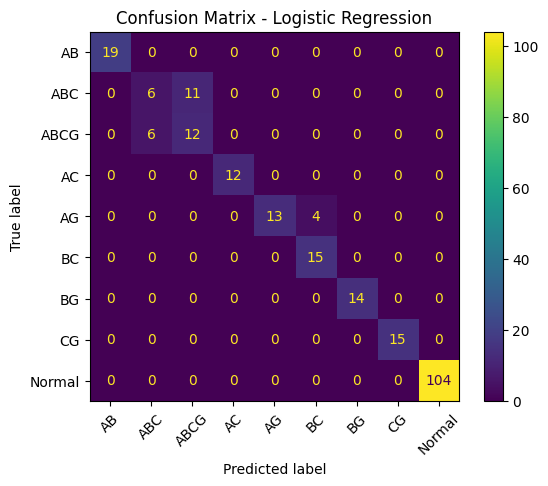


Classification Report:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        19
         ABC       0.50      0.35      0.41        17
        ABCG       0.52      0.67      0.59        18
          AC       1.00      1.00      1.00        12
          AG       1.00      0.76      0.87        17
          BC       0.79      1.00      0.88        15
          BG       1.00      1.00      1.00        14
          CG       1.00      1.00      1.00        15
      Normal       1.00      1.00      1.00       104

    accuracy                           0.91       231
   macro avg       0.87      0.86      0.86       231
weighted avg       0.91      0.91      0.91       231



In [9]:
# Train a Logistic Regression model (multinomial)
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)
# Predict on the test set
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fault_classes)
disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.xticks(rotation=45)
plt.show()
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=fault_classes))


Model 2: **MLP**

In [10]:
mlp = Sequential()
mlp.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
mlp.add(Dense(64, activation='relu'))
mlp.add(Dense(32, activation='relu'))
mlp.add(Dense(num_classes, activation='softmax'))
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
mlp.fit(X_train, y_train, epochs=5000, verbose=0)

# Compare the R2 scores from training and test data.
train_pred_mlp = mlp.predict(X_train, verbose=0)
test_pred_mlp = mlp.predict(X_test, verbose=0)



# Classification metrics for MLP (argmax predictions)
train_pred_class = np.argmax(train_pred_mlp, axis=1)
test_pred_class = np.argmax(test_pred_mlp, axis=1)

train_acc_mlp = accuracy_score(y_train, train_pred_class)
test_acc_mlp = accuracy_score(y_test, test_pred_class)
train_prec_mlp = precision_score(y_train, train_pred_class, average='weighted', zero_division=0)
test_prec_mlp = precision_score(y_test, test_pred_class, average='weighted', zero_division=0)

print(f"MLP Accuracy - Training: {train_acc_mlp:.4f}, Test: {test_acc_mlp:.4f}")
print(f"MLP Precision - Training: {train_prec_mlp:.4f}, Test: {test_prec_mlp:.4f}")

plt.show()

/home/user1/codingProjects/CapstoneProject/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

Model 3: __Random Forest__

Random Forest Accuracy - Training: 0.9891, Test: 0.9654
Random Forest Precision - Training: 0.9891, Test: 0.9654


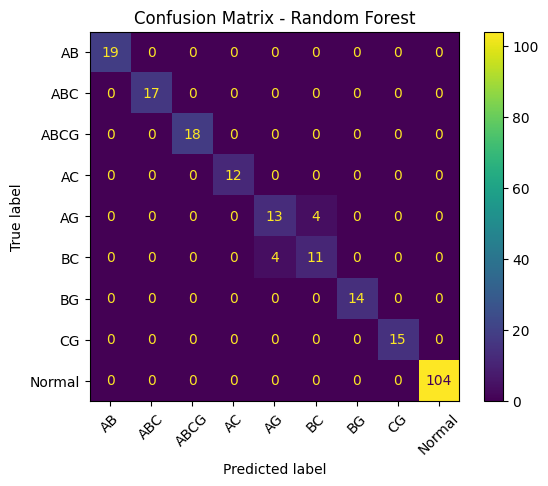


Classification Report:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        19
         ABC       1.00      1.00      1.00        17
        ABCG       1.00      1.00      1.00        18
          AC       1.00      1.00      1.00        12
          AG       0.76      0.76      0.76        17
          BC       0.73      0.73      0.73        15
          BG       1.00      1.00      1.00        14
          CG       1.00      1.00      1.00        15
      Normal       1.00      1.00      1.00       104

    accuracy                           0.97       231
   macro avg       0.94      0.94      0.94       231
weighted avg       0.97      0.97      0.97       231



In [11]:
# Implement Forest for Fault detection
ran_forest = RandomForestClassifier(n_estimators=100, random_state=42)
ran_forest.fit(X_train, y_train)
y_pred_ran = ran_forest.predict(X_test)

# Random Forest metrics
train_pred_rf = ran_forest.predict(X_train)
test_pred_rf = ran_forest.predict(X_test)

train_acc_rand = accuracy_score(y_train, train_pred_rf)
test_acc_rand = accuracy_score(y_test, test_pred_rf)
train_prec_rand = precision_score(y_train, train_pred_rf, average='weighted', zero_division=0)
test_prec_rand = precision_score(y_test, test_pred_rf, average='weighted', zero_division=0)

print(f"Random Forest Accuracy - Training: {train_acc_rand:.4f}, Test: {test_acc_rand:.4f}")
print(f"Random Forest Precision - Training: {train_prec_rand:.4f}, Test: {test_prec_rand:.4f}")
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ran)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fault_classes)
disp.plot()
plt.title('Confusion Matrix - Random Forest')
plt.xticks(rotation=45)
plt.show()
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_ran, target_names=fault_classes))


/home/user1/codingProjects/CapstoneProject/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


CNN Accuracy - Training: 0.9881, Test: 0.9610
CNN Precision - Training: 0.9900, Test: 0.9607


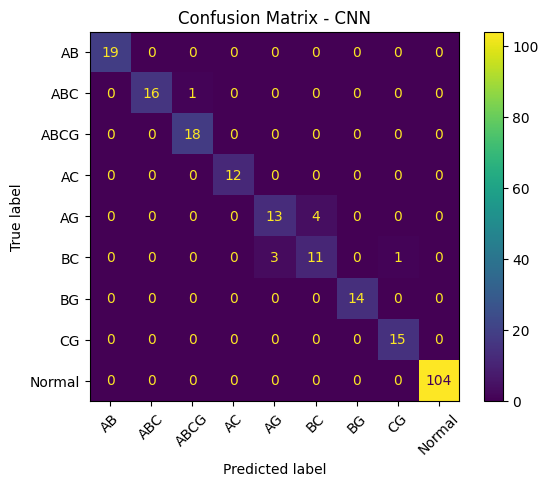


Classification Report:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        19
         ABC       1.00      0.94      0.97        17
        ABCG       0.95      1.00      0.97        18
          AC       1.00      1.00      1.00        12
          AG       0.81      0.76      0.79        17
          BC       0.73      0.73      0.73        15
          BG       1.00      1.00      1.00        14
          CG       0.94      1.00      0.97        15
      Normal       1.00      1.00      1.00       104

    accuracy                           0.96       231
   macro avg       0.94      0.94      0.94       231
weighted avg       0.96      0.96      0.96       231



In [12]:
# implement CNN for fault detection
cnn = Sequential()
cnn.add(layers.Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)))
cnn.add(layers.Conv1D(64, kernel_size=3, activation='relu'))
cnn.add(layers.MaxPooling1D(pool_size=2))
cnn.add(layers.Conv1D(128, kernel_size=3, activation='relu'))
cnn.add(layers.GlobalMaxPooling1D())
cnn.add(layers.Dense(64, activation='relu'))
cnn.add(layers.Dense(num_classes, activation='softmax'))
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
cnn.fit(X_train, y_train, epochs=5000, verbose=0)
# CNN metrics
train_pred_cnn = cnn.predict(X_train, verbose=0)
test_pred_cnn = cnn.predict(X_test, verbose=0)
train_pred_class_cnn = np.argmax(train_pred_cnn, axis=1)
test_pred_class_cnn = np.argmax(test_pred_cnn, axis=1)
train_acc_cnn = accuracy_score(y_train, train_pred_class_cnn)
test_acc_cnn = accuracy_score(y_test, test_pred_class_cnn)
train_prec_cnn = precision_score(y_train, train_pred_class_cnn, average='weighted', zero_division=0)
test_prec_cnn = precision_score(y_test, test_pred_class_cnn, average='weighted', zero_division=0)
print(f"CNN Accuracy - Training: {train_acc_cnn:.4f}, Test: {test_acc_cnn:.4f}")
print(f"CNN Precision - Training: {train_prec_cnn:.4f}, Test: {test_prec_cnn:.4f}")
# Confusion Matrix
cm = confusion_matrix(y_test, test_pred_class_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fault_classes)
disp.plot()
plt.title('Confusion Matrix - CNN')
plt.xticks(rotation=45)
plt.show()
# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, test_pred_class_cnn, target_names=fault_classes))




## Analysis on Combined Dataset

The following section combines `Line_fault_dataset.csv` and `classData.csv` to train the models on a larger, more diverse dataset. The feature set is constrained to the 6 core voltage/current measurements common to both datasets.

Shape of combined data: (1152, 7)

Fault type distribution in combined data:
Fault_Type
Normal    576
ABCG       72
ABC        72
AB         72
BC         72
AC         72
AG         72
CG         72
BG         72
Name: count, dtype: int64

--- Training Logistic Regression on Combined Data ---
Logistic Regression - Combined Data Results:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        14
         ABC       0.33      0.43      0.38        14
        ABCG       0.20      0.14      0.17        14
          AC       1.00      1.00      1.00        15
          AG       1.00      0.87      0.93        15
          BC       0.88      1.00      0.93        14
          BG       1.00      1.00      1.00        15
          CG       1.00      1.00      1.00        14
      Normal       1.00      1.00      1.00       116

    accuracy                           0.90       231
   macro avg       0.82      0.83      0.82       231
weighted a

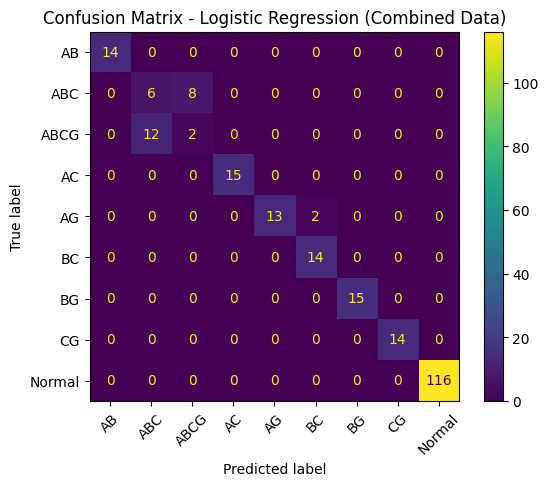


--- Training Random Forest on Combined Data ---
Random Forest - Combined Data Results:
              precision    recall  f1-score   support

          AB       1.00      1.00      1.00        14
         ABC       1.00      1.00      1.00        14
        ABCG       1.00      1.00      1.00        14
          AC       1.00      1.00      1.00        15
          AG       0.76      0.87      0.81        15
          BC       0.83      0.71      0.77        14
          BG       1.00      1.00      1.00        15
          CG       1.00      1.00      1.00        14
      Normal       1.00      1.00      1.00       116

    accuracy                           0.97       231
   macro avg       0.96      0.95      0.95       231
weighted avg       0.97      0.97      0.97       231



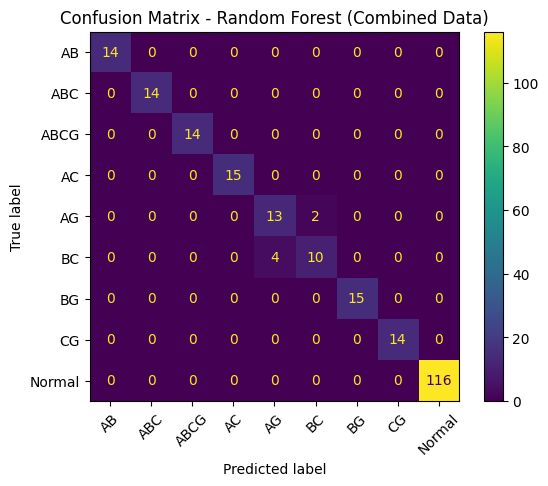

In [ ]:
# --- 1. Load and Process Line_fault_dataset.csv ---
data1 = pd.read_csv('Line_fault_dataset.csv')

# Define fault type function
def get_fault_type(row):
    faults = []
    if row.get('A', 0): faults.append('A')
    if row.get('B', 0): faults.append('B')
    if row.get('C', 0): faults.append('C')
    if row.get('G', 0): faults.append('G')
    return 'Normal' if not faults else ''.join(faults)

data1['Fault_Type'] = data1.apply(get_fault_type, axis=1)

# Select and rename core features
core_features = ['Va_rms', 'Vb_rms', 'Vc_rms', 'Ia_rms', 'Ib_rms', 'Ic_rms', 'Fault_Type']
data1_processed = data1[core_features]

# --- 2. Load and Process classData.csv ---
data2 = pd.read_csv('classData.csv')

# Create Fault_Type
data2['Fault_Type'] = data2.apply(get_fault_type, axis=1)

# Rename columns to match data1
rename_map = {'Va': 'Va_rms', 'Vb': 'Vb_rms', 'Vc': 'Vc_rms', 'Ia': 'Ia_rms', 'Ib': 'Ib_rms', 'Ic': 'Ic_rms'}
data2_renamed = data2.rename(columns=rename_map)

# Select the same core features
data2_processed = data2_renamed[core_features]

# --- 3. Concatenate and Prepare Final Dataset ---
#combined_data = pd.concat([data1_processed, data2_processed], ignore_index=True)
combined_data = data1_processed
print('Shape of combined data:', combined_data.shape)
print('\nFault type distribution in combined data:')
print(combined_data['Fault_Type'].value_counts())

# Encode labels
le_combined = LabelEncoder()
y_combined = le_combined.fit_transform(combined_data['Fault_Type'])
X_combined = combined_data.drop(columns=['Fault_Type']).values

# Store classes for later use
fault_classes_combined = le_combined.classes_

# Standardize and Split
scaler_combined = StandardScaler()
X_scaled_combined = scaler_combined.fit_transform(X_combined)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined)

# --- 4. Model Training and Evaluation ---

# --- Logistic Regression ---
print('\n--- Training Logistic Regression on Combined Data ---')
lr_combined = LogisticRegression(max_iter=1000, solver='lbfgs')
lr_combined.fit(X_train_c, y_train_c)
y_pred_lr_c = lr_combined.predict(X_test_c)
print('Logistic Regression - Combined Data Results:')
print(classification_report(y_test_c, y_pred_lr_c, target_names=fault_classes_combined))

cm_lr_c = confusion_matrix(y_test_c, y_pred_lr_c)
disp_lr_c = ConfusionMatrixDisplay(confusion_matrix=cm_lr_c, display_labels=fault_classes_combined)
disp_lr_c.plot()
plt.title('Confusion Matrix - Logistic Regression (Combined Data)')
plt.xticks(rotation=45)
plt.show()
accuracy_lr_c = accuracy_score(y_test_c, y_pred_lr_c)
precision_lr_c = precision_score(y_test_c, y_pred_lr_c, average='weighted', zero_division=0)

# --- Random Forest ---
print('\n--- Training Random Forest on Combined Data ---')
rf_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_combined.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_combined.predict(X_test_c)
print('Random Forest - Combined Data Results:')
print(classification_report(y_test_c, y_pred_rf_c, target_names=fault_classes_combined))

cm_rf_c = confusion_matrix(y_test_c, y_pred_rf_c)
disp_rf_c = ConfusionMatrixDisplay(confusion_matrix=cm_rf_c, display_labels=fault_classes_combined)
disp_rf_c.plot()
plt.title('Confusion Matrix - Random Forest (Combined Data)')
plt.xticks(rotation=45)
plt.show()


In [15]:
# hybrid model (CNN + Random Forest)
print('\n--- Training Hybrid Model (CNN + Random Forest) on Combined Data ---')

X_train_c = X_train
X_test_c = X_test
y_train_c = y_train
y_test_c = y_test

# CNN part
cnn_hybrid = Sequential()
cnn_hybrid.add(layers.Reshape((X_train_c.shape[1], 1), input_shape=(X_train_c.shape[1],)))
cnn_hybrid.add(layers.Conv1D(64, kernel_size=3, activation='relu'))
cnn_hybrid.add(layers.MaxPooling1D(pool_size=2))
cnn_hybrid.add(layers.Conv1D(128, kernel_size=3, activation='relu'))
cnn_hybrid.add(layers.GlobalMaxPooling1D())
cnn_hybrid.add(layers.Dense(64, activation='relu'))
cnn_hybrid.add(layers.Dense(num_classes, activation='softmax'))
cnn_hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
cnn_hybrid.fit(X_train_c, y_train_c, epochs=5000, verbose=0)
# Get CNN predictions and use as features for Random Forest
train_pred_cnn_hybrid = cnn_hybrid.predict(X_train_c, verbose=0)
test_pred_cnn_hybrid = cnn_hybrid.predict(X_test_c, verbose=0)
train_pred_class_cnn_hybrid = np.argmax(train_pred_cnn_hybrid, axis=1)
test_pred_class_cnn_hybrid = np.argmax(test_pred_cnn_hybrid, axis=1)
# Combine CNN predictions with original features
X_train_hybrid = np.hstack((X_train_c, train_pred_cnn_hybrid))
X_test_hybrid = np.hstack((X_test_c, test_pred_cnn_hybrid))
# Train Random Forest on combined features
rf_hybrid = RandomForestClassifier(n_estimators=100, random_state=42)
rf_hybrid.fit(X_train_hybrid, y_train_c)
y_pred_rf_hybrid = rf_hybrid.predict(X_test_hybrid)
print('Hybrid Model (CNN + Random Forest) - Combined Data Results:')

train_acc_rf_hybrid = accuracy_score(y_train_c, rf_hybrid.predict(X_train_hybrid))
test_acc_rf_hybrid = accuracy_score(y_test_c, y_pred_rf_hybrid)
train_prec_rf_hybrid = precision_score(y_train_c, rf_hybrid.predict(X_train_hybrid), average='weighted', zero_division=0)
test_prec_rf_hybrid = precision_score(y_test_c, y_pred_rf_hybrid, average='weighted', zero_division=0)
print(f"Hybrid Model Accuracy - Training: {train_acc_rf_hybrid:.4f}, Test: {test_acc_rf_hybrid:.4f}")
print(f"Hybrid Model Precision - Training: {train_prec_rf_hybrid:.4f}, Test: {test_prec_rf_hybrid:.4f}")

print(classification_report(y_test_c, y_pred_rf_hybrid, target_names=fault_classes_combined))
cm_rf_hybrid = confusion_matrix(y_test_c, y_pred_rf_hybrid)
disp_rf_hybrid = ConfusionMatrixDisplay(confusion_matrix=cm_rf_hybrid, display_labels=fault_classes_combined)
disp_rf_hybrid.plot()
plt.title('Confusion Matrix - Hybrid Model (Combined Data)')
plt.xticks(rotation=45)
plt.show()

#Combined data



--- Training Hybrid Model (CNN + Random Forest) on Combined Data ---


/home/user1/codingProjects/CapstoneProject/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Hybrid Model (CNN + Random Forest) - Combined Data Results:
Hybrid Model Accuracy - Training: 0.9891, Test: 0.9610
Hybrid Model Precision - Training: 0.9891, Test: 0.9613


NameError: name 'fault_classes_combined' is not defined